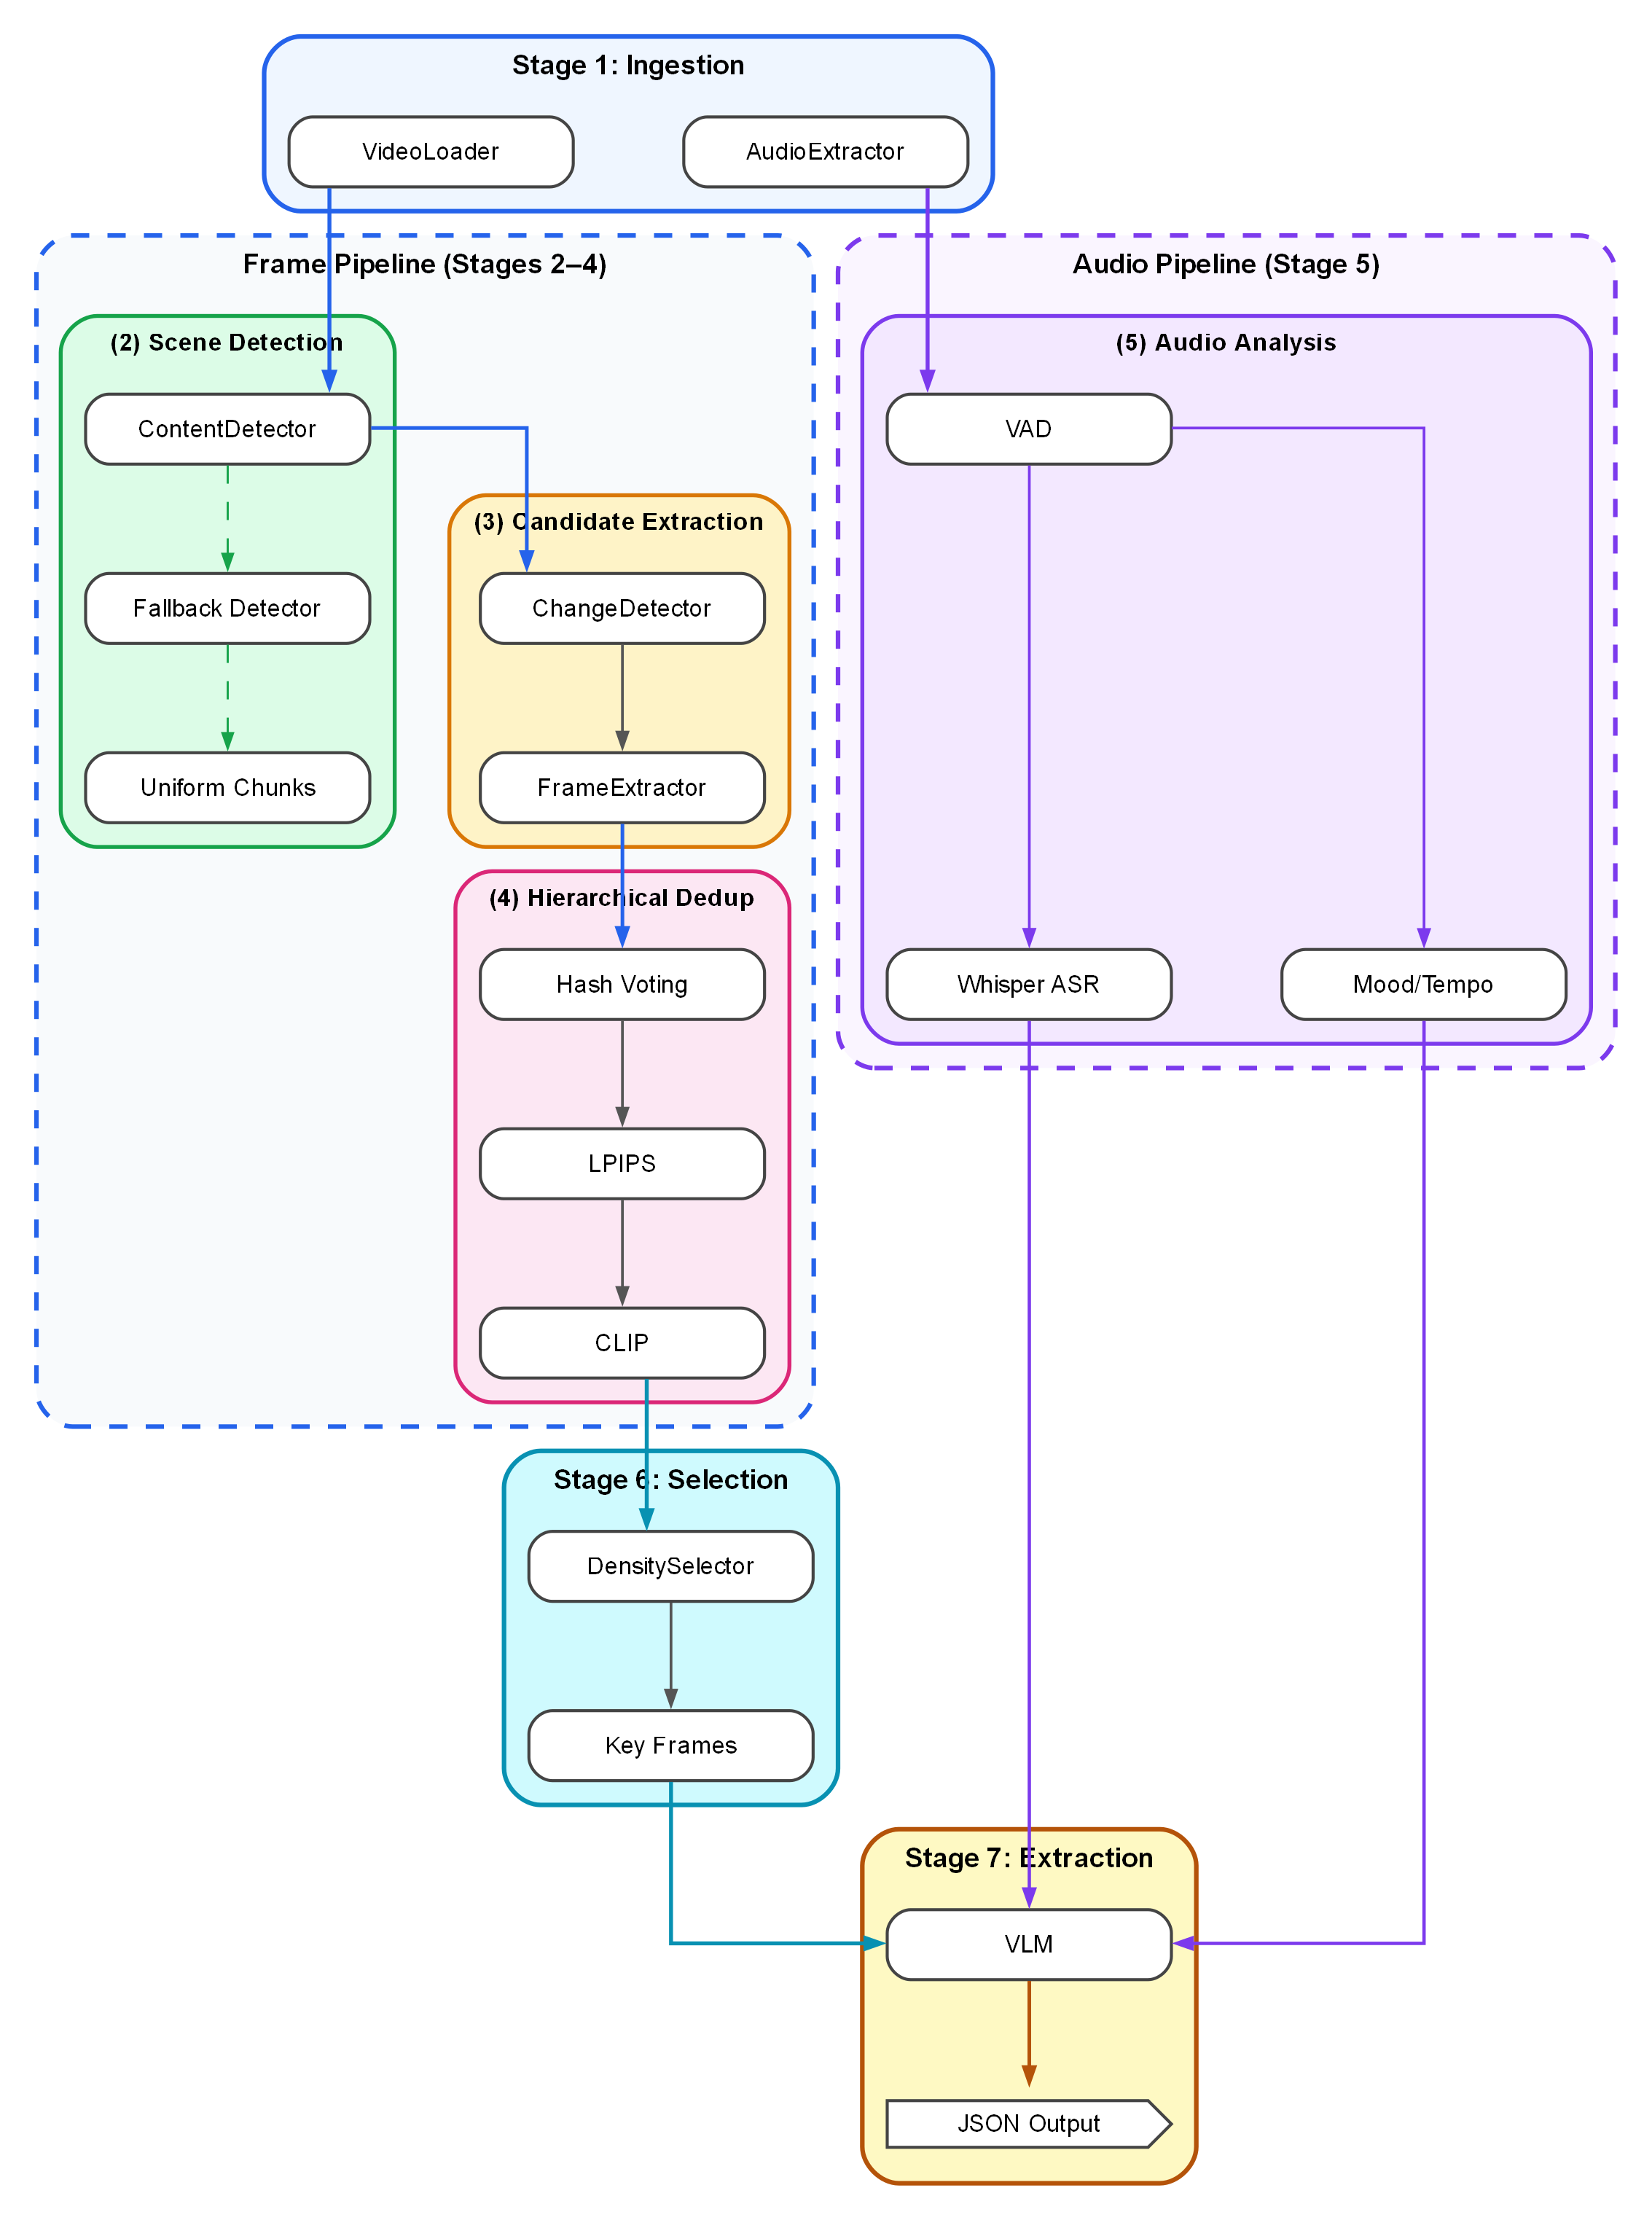

In [6]:
from graphviz import Digraph

dot = Digraph('Video_Ad_Analysis_Pipeline')

# ===== GLOBAL STYLING =====
dot.attr(
    rankdir='TB',
    splines='ortho',  # Orthogonal edges for cleaner look
    nodesep='0.5',
    ranksep='0.5',
    fontname='Helvetica',
    fontsize='10',
    bgcolor='white',
    dpi='300',
    compound='true',
    newrank='true'
)

dot.attr('node',
    shape='box',
    style='filled,rounded',
    fillcolor='white',
    color='#444444',
    fontname='Helvetica',
    fontsize='8',
    height='0.32',
    width='1.3',
    margin='0.06,0.04'
)

dot.attr('edge',
    color='#555555',
    arrowsize='0.5',
    penwidth='0.9'
)

# Colors
BLUE = '#2563EB'
GREEN = '#16A34A'
AMBER = '#D97706'
PINK = '#DB2777'
PURPLE = '#7C3AED'
CYAN = '#0891B2'
GOLD = '#B45309'
GRAY = '#6B7280'

# ===== STAGE 1: INGESTION =====
with dot.subgraph(name='cluster_ingest') as c:
    c.attr(label='Stage 1: Ingestion', style='filled,rounded',
           fillcolor='#EFF6FF', color=BLUE, penwidth='1.5',
           fontname='Helvetica-Bold', fontsize='9')
    c.node('VL', 'VideoLoader')
    c.node('AE', 'AudioExtractor')

# ===== FRAME PIPELINE (Stages 2-4) =====
with dot.subgraph(name='cluster_frame_pipeline') as fp:
    fp.attr(label='Frame Pipeline (Stages 2–4)', style='filled,dashed,rounded',
            fillcolor='#F8FAFC', color=BLUE, penwidth='1.5',
            fontname='Helvetica-Bold', fontsize='9')
    
    # Stage 2: Scene Detection
    with fp.subgraph(name='cluster_scene') as c:
        c.attr(label='(2) Scene Detection', style='filled,rounded',
               fillcolor='#DCFCE7', color=GREEN, penwidth='1.3',
               fontname='Helvetica-Bold', fontsize='8')
        c.node('SD1', 'ContentDetector')
        c.node('SD2', 'Fallback Detector')
        c.node('SD3', 'Uniform Chunks')
    
    # Stage 3: Candidate Extraction
    with fp.subgraph(name='cluster_candidate') as c:
        c.attr(label='(3) Candidate Extraction', style='filled,rounded',
               fillcolor='#FEF3C7', color=AMBER, penwidth='1.3',
               fontname='Helvetica-Bold', fontsize='8')
        c.node('CD', 'ChangeDetector')
        c.node('CFE', 'FrameExtractor')
    
    # Stage 4: Deduplication  
    with fp.subgraph(name='cluster_dedup') as c:
        c.attr(label='(4) Hierarchical Dedup', style='filled,rounded',
               fillcolor='#FCE7F3', color=PINK, penwidth='1.3',
               fontname='Helvetica-Bold', fontsize='8')
        c.node('HASH', 'Hash Voting')
        c.node('LPIPS', 'LPIPS')
        c.node('CLIP', 'CLIP')

# ===== AUDIO PIPELINE (Stage 5) =====
with dot.subgraph(name='cluster_audio_pipeline') as ap:
    ap.attr(label='Audio Pipeline (Stage 5)', style='filled,dashed,rounded',
            fillcolor='#FAF5FF', color=PURPLE, penwidth='1.5',
            fontname='Helvetica-Bold', fontsize='9')
    
    with ap.subgraph(name='cluster_audio') as c:
        c.attr(label='(5) Audio Analysis', style='filled,rounded',
               fillcolor='#F3E8FF', color=PURPLE, penwidth='1.3',
               fontname='Helvetica-Bold', fontsize='8')
        c.node('VAD', 'VAD')
        c.node('WHISPER', 'Whisper ASR')
        c.node('MOOD', 'Mood/Tempo')

# ===== STAGE 6: SELECTION =====
with dot.subgraph(name='cluster_select') as c:
    c.attr(label='Stage 6: Selection', style='filled,rounded',
           fillcolor='#CFFAFE', color=CYAN, penwidth='1.5',
           fontname='Helvetica-Bold', fontsize='9')
    c.node('SEL', 'DensitySelector')
    c.node('KEY', 'Key Frames')

# ===== STAGE 7: LLM EXTRACTION =====
with dot.subgraph(name='cluster_llm') as c:
    c.attr(label='Stage 7: Extraction', style='filled,rounded',
           fillcolor='#FEF9C3', color=GOLD, penwidth='1.5',
           fontname='Helvetica-Bold', fontsize='9')
    c.node('LLM', 'VLM')
    c.node('OUT', 'JSON Output', shape='cds', height='0.32')

# ===== LAYOUT CONTROL =====
dot.body.append('{rank=same; VL; AE}')
dot.body.append('{rank=same; SD1; VAD}')
dot.body.append('{rank=same; WHISPER; MOOD}')
dot.body.append('{rank=max; OUT}')

# ===== EDGES: FRAME PIPELINE =====
dot.edge('VL', 'SD1', color=BLUE, penwidth='1.3')

# Scene detection fallback chain
dot.edge('SD1', 'SD2', style='dashed', color=GREEN, penwidth='0.7')
dot.edge('SD2', 'SD3', style='dashed', color=GREEN, penwidth='0.7')

# Scene to candidate
dot.edge('SD1', 'CD', color=BLUE, penwidth='1.2')
dot.edge('CD', 'CFE')

# Candidate to deduplication
dot.edge('CFE', 'HASH', color=BLUE, penwidth='1.2')
dot.edge('HASH', 'LPIPS')
dot.edge('LPIPS', 'CLIP')

# ===== EDGES: AUDIO PIPELINE =====
dot.edge('AE', 'VAD', color=PURPLE, penwidth='1.3')
dot.edge('VAD', 'WHISPER', color=PURPLE)
dot.edge('VAD', 'MOOD', color=PURPLE)

# ===== EDGES: SELECTION =====
dot.edge('CLIP', 'SEL', color=CYAN, penwidth='1.3')
dot.edge('SEL', 'KEY')

# ===== EDGES: LLM (convergence) =====
dot.edge('KEY', 'LLM', color=CYAN, penwidth='1.3')
dot.edge('WHISPER', 'LLM', color=PURPLE, penwidth='1.1')
dot.edge('MOOD', 'LLM', color=PURPLE, penwidth='1.1')

# Output
dot.edge('LLM', 'OUT', color=GOLD, penwidth='1.2')

# ===== IN-MEMORY RENDERING (for Jupyter) =====
from IPython.display import Image
img_bytes = dot.pipe(format='png')
Image(img_bytes)

# To save files, uncomment:
# dot.format = 'pdf'
# dot.render('ad_pipeline', cleanup=True)


(process:6724): Pango-WARNING **: 20:02:58.997: couldn't load font "Arial-Bold Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

(process:6724): Pango-WARNING **: 20:02:59.015: couldn't load font "Arial-Bold Not-Rotated 12", falling back to "Sans Not-Rotated 12", expect ugly output.

(process:6724): Pango-WARNING **: 20:02:59.018: couldn't load font "Arial-Bold Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.


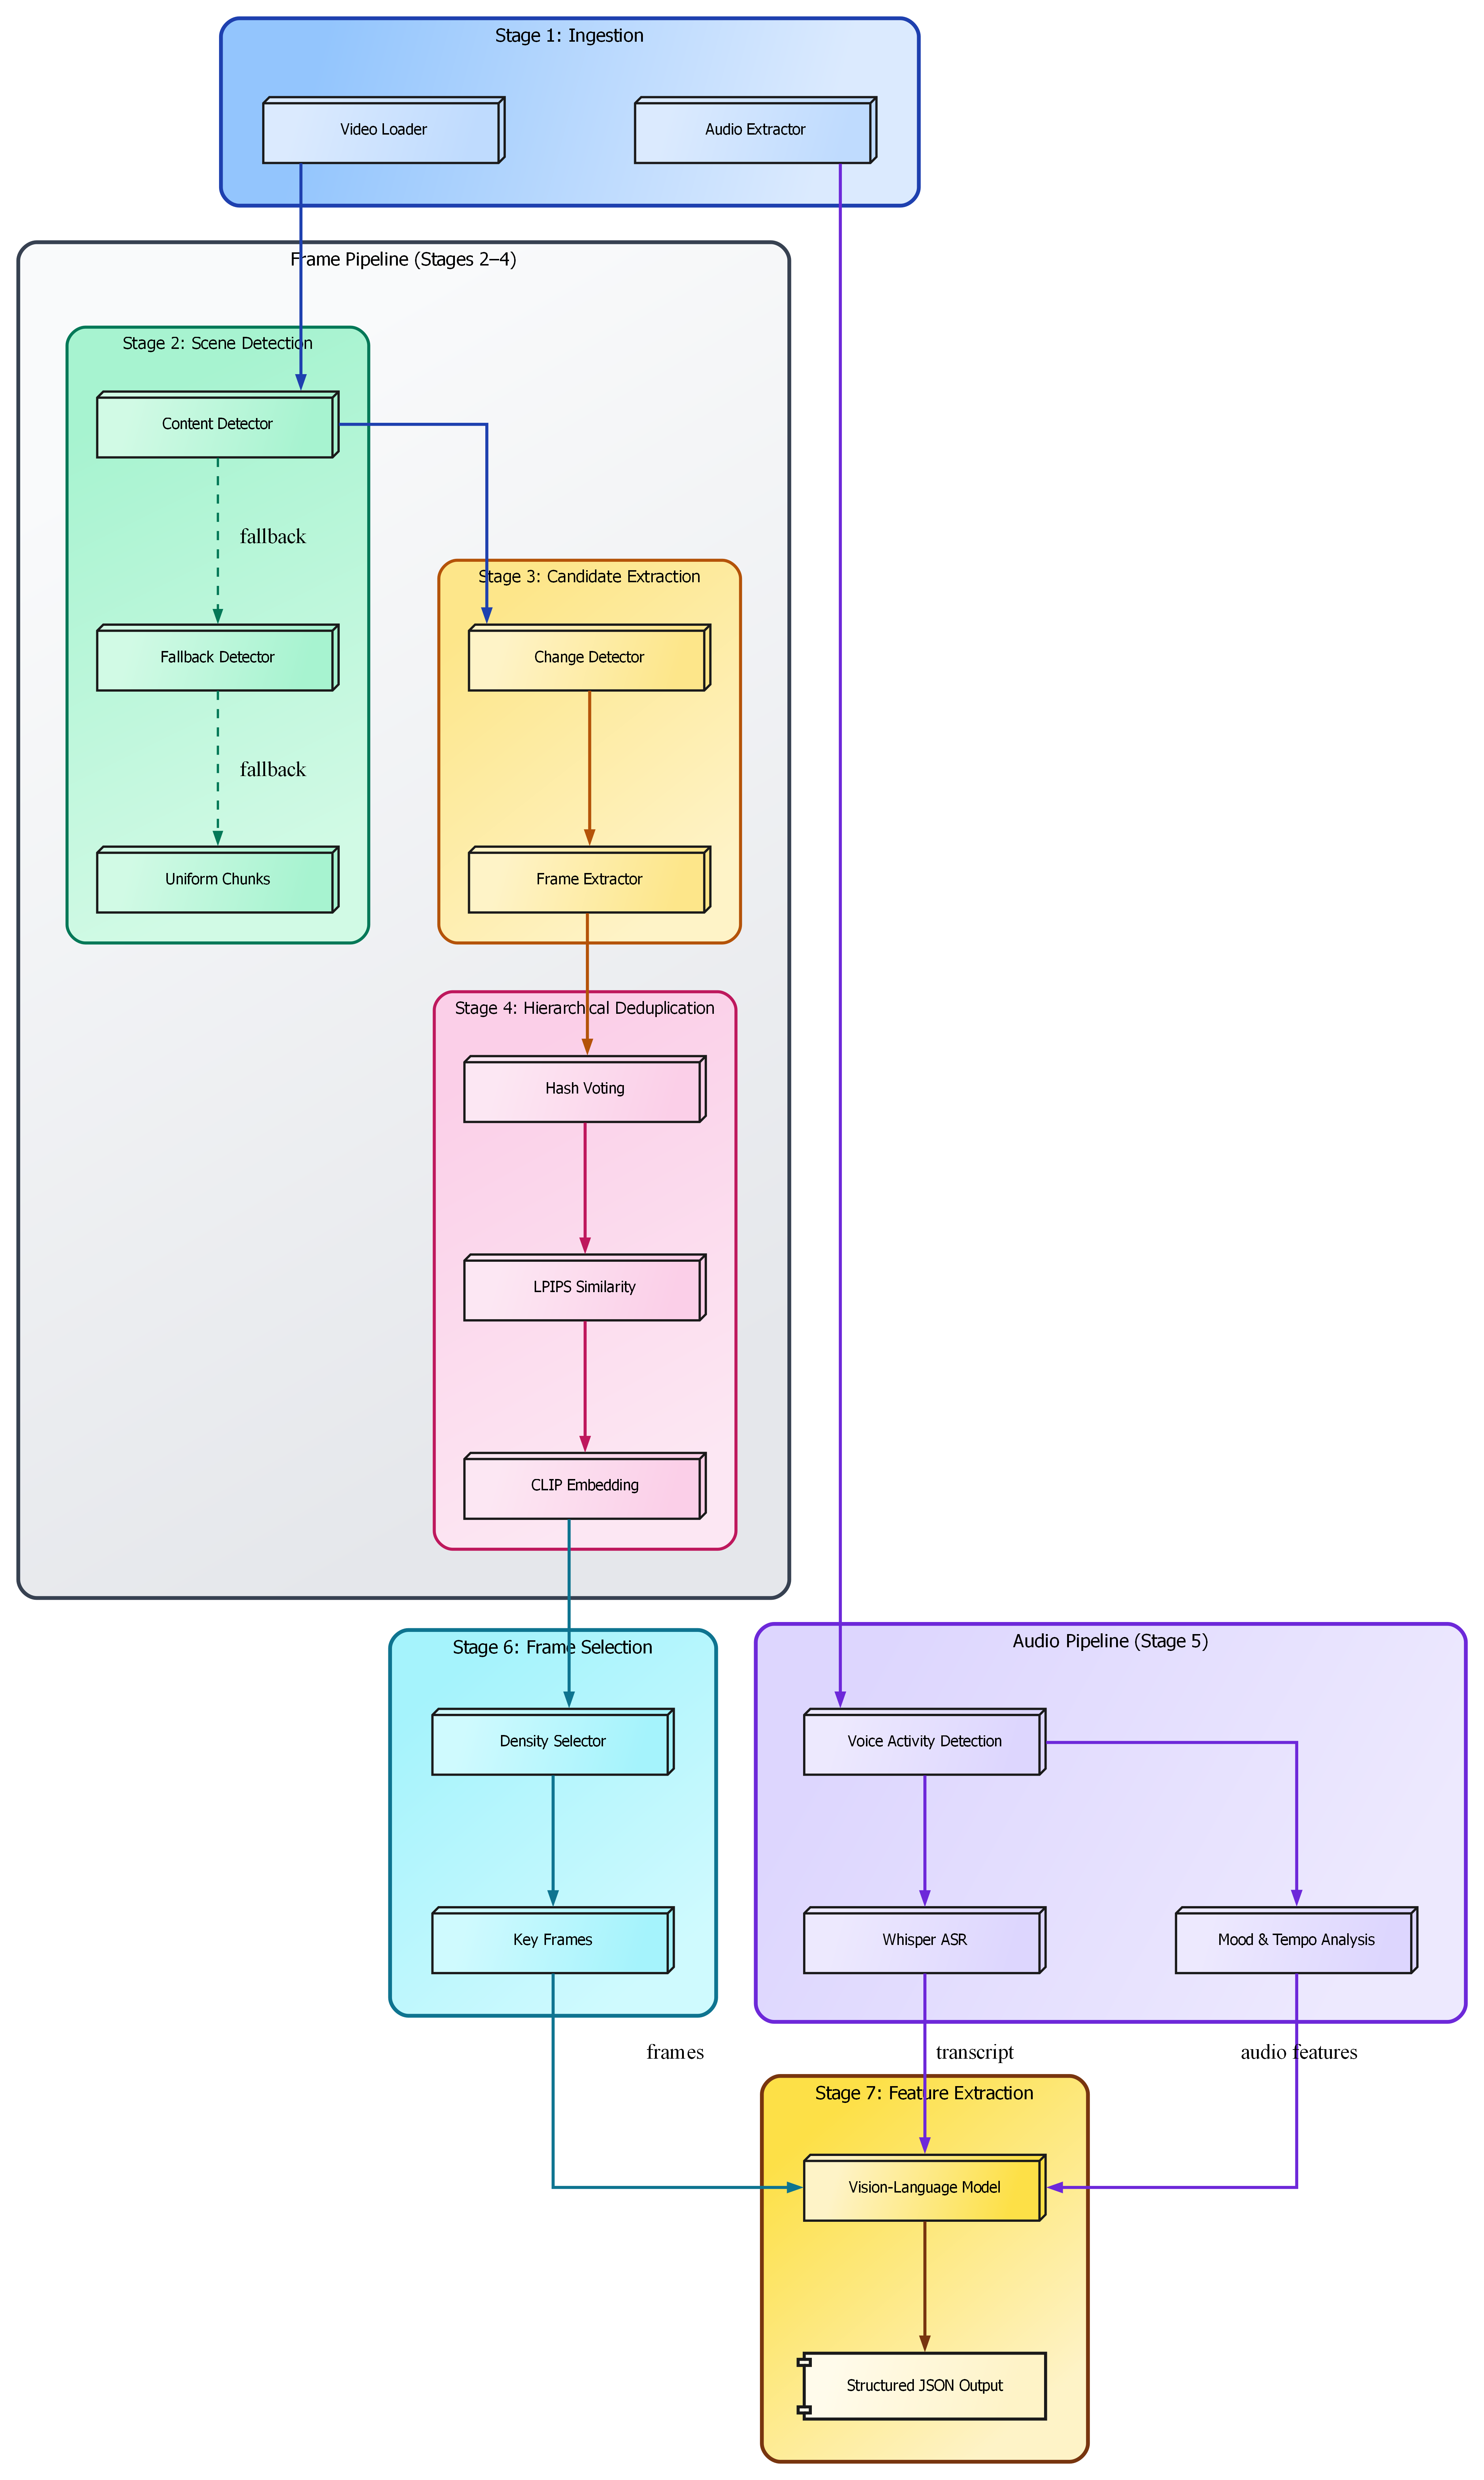

In [10]:
from graphviz import Digraph

dot = Digraph('Video_Ad_Analysis_Pipeline')

# ===== GLOBAL STYLING =====
dot.attr(
    rankdir='TB',
    splines='ortho',
    nodesep='1.2',
    ranksep='1.2',
    fontname='Arial',
    fontsize='11',
    bgcolor='white',
    dpi='300',
    compound='true'
)

dot.attr('node',
    shape='box3d',  # 3D effect
    style='filled',
    fillcolor='white',
    color='#1a1a1a',
    fontname='Arial-Bold',
    fontsize='10',
    height='0.6',
    width='2.2',
    margin='0.2,0.12',
    penwidth='1.5',
    gradientangle='270'
)

dot.attr('edge',
    color='#2a2a2a',
    arrowsize='0.7',
    penwidth='1.8'
)

# Colors with gradients
BLUE_LIGHT = '#3B82F6'
BLUE_DARK = '#1E40AF'
GREEN_LIGHT = '#10B981'
GREEN_DARK = '#047857'
AMBER_LIGHT = '#F59E0B'
AMBER_DARK = '#B45309'
PINK_LIGHT = '#EC4899'
PINK_DARK = '#BE185D'
PURPLE_LIGHT = '#8B5CF6'
PURPLE_DARK = '#6D28D9'
CYAN_LIGHT = '#06B6D4'
CYAN_DARK = '#0E7490'
GOLD_LIGHT = '#F59E0B'
GOLD_DARK = '#78350F'

# ===== STAGE 1: INGESTION =====
with dot.subgraph(name='cluster_ingest') as c:
    c.attr(
        label='Stage 1: Ingestion',
        style='filled,rounded',
        fillcolor='#DBEAFE:#93C5FD',  # Gradient
        color=BLUE_DARK,
        penwidth='2.5',
        fontname='Arial-Bold',
        fontsize='12',
        margin='28',
        gradientangle='135'
    )
    c.node('VL', 'Video Loader', fillcolor='#BFDBFE:#DBEAFE', gradientangle='135')
    c.node('AE', 'Audio Extractor', fillcolor='#BFDBFE:#DBEAFE', gradientangle='135')

# ===== FRAME PIPELINE =====
with dot.subgraph(name='cluster_frame') as fp:
    fp.attr(
        label='Frame Pipeline (Stages 2–4)',
        style='filled,rounded',
        fillcolor='#E5E7EB:#F9FAFB',  # Gradient
        color='#374151',
        penwidth='2.5',
        fontname='Arial-Bold',
        fontsize='12',
        margin='32',
        gradientangle='135'
    )
    
    # Stage 2
    with fp.subgraph(name='cluster_scene') as c:
        c.attr(
            label='Stage 2: Scene Detection',
            style='filled,rounded',
            fillcolor='#D1FAE5:#A7F3D0',  # Gradient
            color=GREEN_DARK,
            penwidth='2.0',
            fontname='Arial-Bold',
            fontsize='11',
            margin='20',
            gradientangle='135'
        )
        c.node('SD1', 'Content Detector', fillcolor='#A7F3D0:#D1FAE5', gradientangle='135')
        c.node('SD2', 'Fallback Detector', fillcolor='#A7F3D0:#D1FAE5', gradientangle='135')
        c.node('SD3', 'Uniform Chunks', fillcolor='#A7F3D0:#D1FAE5', gradientangle='135')
    
    # Stage 3
    with fp.subgraph(name='cluster_candidate') as c:
        c.attr(
            label='Stage 3: Candidate Extraction',
            style='filled,rounded',
            fillcolor='#FEF3C7:#FDE68A',  # Gradient
            color=AMBER_DARK,
            penwidth='2.0',
            fontname='Arial-Bold',
            fontsize='11',
            margin='20',
            gradientangle='135'
        )
        c.node('CD', 'Change Detector', fillcolor='#FDE68A:#FEF3C7', gradientangle='135')
        c.node('CFE', 'Frame Extractor', fillcolor='#FDE68A:#FEF3C7', gradientangle='135')
    
    # Stage 4
    with fp.subgraph(name='cluster_dedup') as c:
        c.attr(
            label='Stage 4: Hierarchical Deduplication',
            style='filled,rounded',
            fillcolor='#FCE7F3:#FBCFE8',  # Gradient
            color=PINK_DARK,
            penwidth='2.0',
            fontname='Arial-Bold',
            fontsize='11',
            margin='20',
            gradientangle='135'
        )
        c.node('HASH', 'Hash Voting', fillcolor='#FBCFE8:#FCE7F3', gradientangle='135')
        c.node('LPIPS', 'LPIPS Similarity', fillcolor='#FBCFE8:#FCE7F3', gradientangle='135')
        c.node('CLIP', 'CLIP Embedding', fillcolor='#FBCFE8:#FCE7F3', gradientangle='135')

# ===== AUDIO PIPELINE =====
with dot.subgraph(name='cluster_audio') as ap:
    ap.attr(
        label='Audio Pipeline (Stage 5)',
        style='filled,rounded',
        fillcolor='#EDE9FE:#DDD6FE',  # Gradient
        color=PURPLE_DARK,
        penwidth='2.5',
        fontname='Arial-Bold',
        fontsize='12',
        margin='32',
        gradientangle='135'
    )
    
    ap.node('VAD', 'Voice Activity Detection', fillcolor='#DDD6FE:#EDE9FE', gradientangle='135')
    ap.node('WHISPER', 'Whisper ASR', fillcolor='#DDD6FE:#EDE9FE', gradientangle='135')
    ap.node('MOOD', 'Mood & Tempo Analysis', fillcolor='#DDD6FE:#EDE9FE', gradientangle='135')

# ===== STAGE 6: SELECTION =====
with dot.subgraph(name='cluster_select') as c:
    c.attr(
        label='Stage 6: Frame Selection',
        style='filled,rounded',
        fillcolor='#CFFAFE:#A5F3FC',  # Gradient
        color=CYAN_DARK,
        penwidth='2.5',
        fontname='Arial-Bold',
        fontsize='12',
        margin='28',
        gradientangle='135'
    )
    c.node('SEL', 'Density Selector', fillcolor='#A5F3FC:#CFFAFE', gradientangle='135')
    c.node('KEY', 'Key Frames', fillcolor='#A5F3FC:#CFFAFE', gradientangle='135')

# ===== STAGE 7: EXTRACTION =====
with dot.subgraph(name='cluster_llm') as c:
    c.attr(
        label='Stage 7: Feature Extraction',
        style='filled,rounded',
        fillcolor='#FEF3C7:#FDE047',  # Gradient
        color=GOLD_DARK,
        penwidth='2.5',
        fontname='Arial-Bold',
        fontsize='12',
        margin='28',
        gradientangle='135'
    )
    c.node('VLM', 'Vision-Language Model', fillcolor='#FDE047:#FEF3C7', gradientangle='135')
    c.node('OUT', 'Structured JSON Output', shape='component', fillcolor='#FEF3C7:#FFFBEB', gradientangle='135', penwidth='2.0')

# ===== EDGES WITH 3D EFFECT =====
dot.edge('VL', 'SD1', color=BLUE_DARK, penwidth='2.0', style='bold')
dot.edge('SD1', 'SD2', style='dashed', color=GREEN_DARK, label='  fallback', penwidth='1.5')
dot.edge('SD2', 'SD3', style='dashed', color=GREEN_DARK, label='  fallback', penwidth='1.5')
dot.edge('SD1', 'CD', color=BLUE_DARK, penwidth='2.0', style='bold')
dot.edge('CD', 'CFE', color=AMBER_DARK, penwidth='2.0', style='bold')
dot.edge('CFE', 'HASH', color=AMBER_DARK, penwidth='2.0', style='bold')
dot.edge('HASH', 'LPIPS', color=PINK_DARK, penwidth='2.0', style='bold')
dot.edge('LPIPS', 'CLIP', color=PINK_DARK, penwidth='2.0', style='bold')

# ===== EDGES: AUDIO PIPELINE =====
dot.edge('AE', 'VAD', color=PURPLE_DARK, penwidth='2.0', style='bold')
dot.edge('VAD', 'WHISPER', color=PURPLE_DARK, penwidth='2.0', style='bold')
dot.edge('VAD', 'MOOD', color=PURPLE_DARK, penwidth='2.0', style='bold')

# ===== EDGES: CONVERGENCE =====
dot.edge('CLIP', 'SEL', color=CYAN_DARK, penwidth='2.0', style='bold')
dot.edge('SEL', 'KEY', color=CYAN_DARK, penwidth='2.0', style='bold')
dot.edge('KEY', 'VLM', color=CYAN_DARK, penwidth='2.0', style='bold', label='  frames')
dot.edge('WHISPER', 'VLM', color=PURPLE_DARK, penwidth='2.0', style='bold', label='  transcript  ')
dot.edge('MOOD', 'VLM', color=PURPLE_DARK, penwidth='2.0', style='bold', label='  audio features  ')
dot.edge('VLM', 'OUT', color=GOLD_DARK, penwidth='2.0', style='bold')

# ===== RENDERING =====
from IPython.display import Image
img_bytes = dot.pipe(format='png')
Image(img_bytes)

# For paper submission (vector format):
# dot.format = 'pdf'
# dot.render('icmr2026_pipeline_3d', cleanup=True)

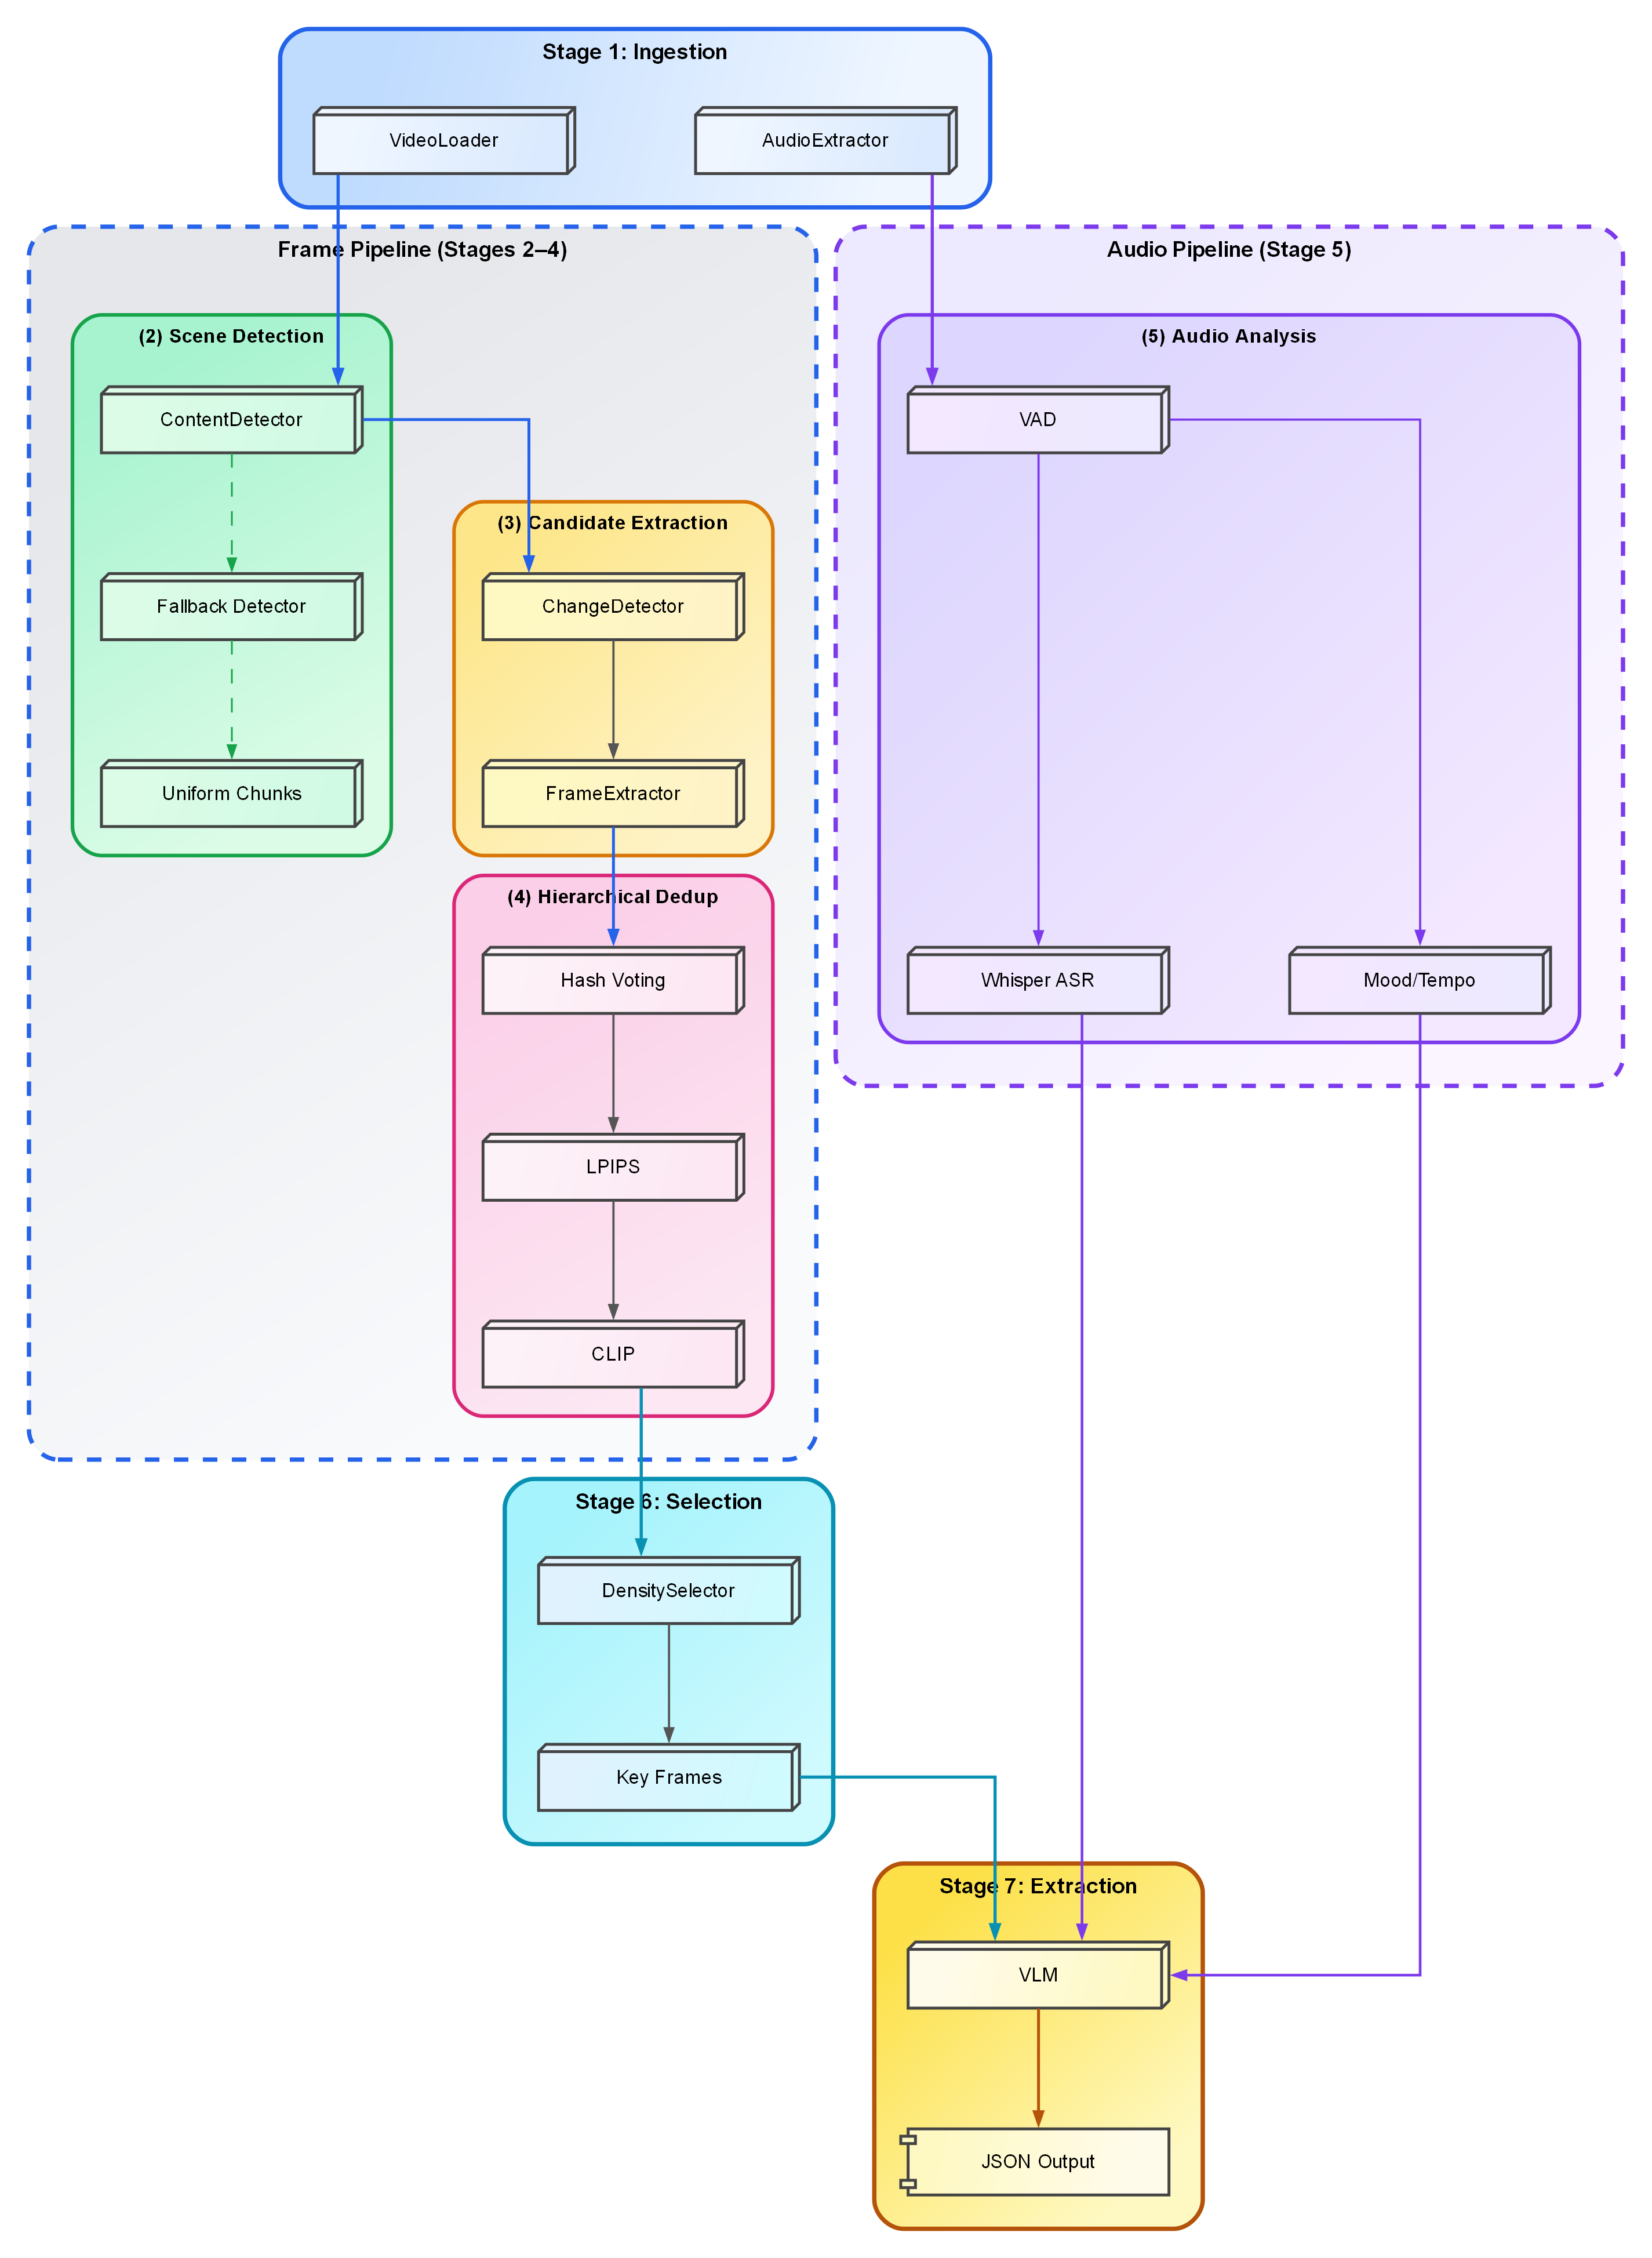

In [11]:
from graphviz import Digraph

dot = Digraph('Video_Ad_Analysis_Pipeline')

# ===== GLOBAL STYLING =====
dot.attr(
    rankdir='TB',
    splines='ortho',
    nodesep='0.7',
    ranksep='0.7',
    fontname='Helvetica',
    fontsize='10',
    bgcolor='white',
    dpi='300',
    compound='true',
    newrank='true'
)

dot.attr('node',
    shape='box3d',
    style='filled',
    fillcolor='white',
    color='#444444',
    fontname='Helvetica',
    fontsize='8',
    height='0.38',
    width='1.5',
    margin='0.08,0.06',
    penwidth='1.2'
)

dot.attr('edge',
    color='#555555',
    arrowsize='0.5',
    penwidth='0.9'
)

# Colors
BLUE = '#2563EB'
GREEN = '#16A34A'
AMBER = '#D97706'
PINK = '#DB2777'
PURPLE = '#7C3AED'
CYAN = '#0891B2'
GOLD = '#B45309'
GRAY = '#6B7280'

# ===== STAGE 1: INGESTION =====
with dot.subgraph(name='cluster_ingest') as c:
    c.attr(label='Stage 1: Ingestion', style='filled,rounded',
           fillcolor='#EFF6FF:#BFDBFE', color=BLUE, penwidth='1.8',
           fontname='Helvetica-Bold', fontsize='9', margin='14',
           gradientangle='135')
    c.node('VL', 'VideoLoader', fillcolor='#DBEAFE:#EFF6FF', gradientangle='135')
    c.node('AE', 'AudioExtractor', fillcolor='#DBEAFE:#EFF6FF', gradientangle='135')

# ===== FRAME PIPELINE (Stages 2-4) =====
with dot.subgraph(name='cluster_frame_pipeline') as fp:
    fp.attr(label='Frame Pipeline (Stages 2–4)', style='filled,dashed,rounded',
            fillcolor='#F8FAFC:#E5E7EB', color=BLUE, penwidth='1.8',
            fontname='Helvetica-Bold', fontsize='9', margin='18',
            gradientangle='135')
    
    # Stage 2: Scene Detection
    with fp.subgraph(name='cluster_scene') as c:
        c.attr(label='(2) Scene Detection', style='filled,rounded',
               fillcolor='#DCFCE7:#A7F3D0', color=GREEN, penwidth='1.5',
               fontname='Helvetica-Bold', fontsize='8', margin='12',
               gradientangle='135')
        c.node('SD1', 'ContentDetector', fillcolor='#D1FAE5:#DCFCE7', gradientangle='135')
        c.node('SD2', 'Fallback Detector', fillcolor='#D1FAE5:#DCFCE7', gradientangle='135')
        c.node('SD3', 'Uniform Chunks', fillcolor='#D1FAE5:#DCFCE7', gradientangle='135')
    
    # Stage 3: Candidate Extraction
    with fp.subgraph(name='cluster_candidate') as c:
        c.attr(label='(3) Candidate Extraction', style='filled,rounded',
               fillcolor='#FEF3C7:#FDE68A', color=AMBER, penwidth='1.5',
               fontname='Helvetica-Bold', fontsize='8', margin='12',
               gradientangle='135')
        c.node('CD', 'ChangeDetector', fillcolor='#FEF3C7:#FEF9C3', gradientangle='135')
        c.node('CFE', 'FrameExtractor', fillcolor='#FEF3C7:#FEF9C3', gradientangle='135')
    
    # Stage 4: Deduplication  
    with fp.subgraph(name='cluster_dedup') as c:
        c.attr(label='(4) Hierarchical Dedup', style='filled,rounded',
               fillcolor='#FCE7F3:#FBCFE8', color=PINK, penwidth='1.5',
               fontname='Helvetica-Bold', fontsize='8', margin='12',
               gradientangle='135')
        c.node('HASH', 'Hash Voting', fillcolor='#FCE7F3:#FDF2F8', gradientangle='135')
        c.node('LPIPS', 'LPIPS', fillcolor='#FCE7F3:#FDF2F8', gradientangle='135')
        c.node('CLIP', 'CLIP', fillcolor='#FCE7F3:#FDF2F8', gradientangle='135')

# ===== AUDIO PIPELINE (Stage 5) =====
with dot.subgraph(name='cluster_audio_pipeline') as ap:
    ap.attr(label='Audio Pipeline (Stage 5)', style='filled,dashed,rounded',
            fillcolor='#FAF5FF:#EDE9FE', color=PURPLE, penwidth='1.8',
            fontname='Helvetica-Bold', fontsize='9', margin='18',
            gradientangle='135')
    
    with ap.subgraph(name='cluster_audio') as c:
        c.attr(label='(5) Audio Analysis', style='filled,rounded',
               fillcolor='#F3E8FF:#DDD6FE', color=PURPLE, penwidth='1.5',
               fontname='Helvetica-Bold', fontsize='8', margin='12',
               gradientangle='135')
        c.node('VAD', 'VAD', fillcolor='#EDE9FE:#F3E8FF', gradientangle='135')
        c.node('WHISPER', 'Whisper ASR', fillcolor='#EDE9FE:#F3E8FF', gradientangle='135')
        c.node('MOOD', 'Mood/Tempo', fillcolor='#EDE9FE:#F3E8FF', gradientangle='135')

# ===== STAGE 6: SELECTION =====
with dot.subgraph(name='cluster_select') as c:
    c.attr(label='Stage 6: Selection', style='filled,rounded',
           fillcolor='#CFFAFE:#A5F3FC', color=CYAN, penwidth='1.8',
           fontname='Helvetica-Bold', fontsize='9', margin='14',
           gradientangle='135')
    c.node('SEL', 'DensitySelector', fillcolor='#CFFAFE:#E0F2FE', gradientangle='135')
    c.node('KEY', 'Key Frames', fillcolor='#CFFAFE:#E0F2FE', gradientangle='135')

# ===== STAGE 7: LLM EXTRACTION =====
with dot.subgraph(name='cluster_llm') as c:
    c.attr(label='Stage 7: Extraction', style='filled,rounded',
           fillcolor='#FEF9C3:#FDE047', color=GOLD, penwidth='1.8',
           fontname='Helvetica-Bold', fontsize='9', margin='14',
           gradientangle='135')
    c.node('LLM', 'VLM', fillcolor='#FEF9C3:#FFFBEB', gradientangle='135')
    c.node('OUT', 'JSON Output', shape='component', height='0.38',
           fillcolor='#FFFBEB:#FEF9C3', gradientangle='135', penwidth='1.2')

# ===== LAYOUT CONTROL =====
dot.body.append('{rank=same; VL; AE}')
dot.body.append('{rank=same; SD1; VAD}')
dot.body.append('{rank=same; WHISPER; MOOD}')
dot.body.append('{rank=max; OUT}')

# ===== EDGES: FRAME PIPELINE =====
dot.edge('VL', 'SD1', color=BLUE, penwidth='1.3', style='bold')

# Scene detection fallback chain
dot.edge('SD1', 'SD2', style='dashed', color=GREEN, penwidth='0.7')
dot.edge('SD2', 'SD3', style='dashed', color=GREEN, penwidth='0.7')

# Scene to candidate
dot.edge('SD1', 'CD', color=BLUE, penwidth='1.2', style='bold')
dot.edge('CD', 'CFE')

# Candidate to deduplication
dot.edge('CFE', 'HASH', color=BLUE, penwidth='1.2', style='bold')
dot.edge('HASH', 'LPIPS')
dot.edge('LPIPS', 'CLIP')

# ===== EDGES: AUDIO PIPELINE =====
dot.edge('AE', 'VAD', color=PURPLE, penwidth='1.3', style='bold')
dot.edge('VAD', 'WHISPER', color=PURPLE)
dot.edge('VAD', 'MOOD', color=PURPLE)

# ===== EDGES: SELECTION =====
dot.edge('CLIP', 'SEL', color=CYAN, penwidth='1.3', style='bold')
dot.edge('SEL', 'KEY')

# ===== EDGES: LLM (convergence) =====
dot.edge('KEY', 'LLM', color=CYAN, penwidth='1.3', style='bold')
dot.edge('WHISPER', 'LLM', color=PURPLE, penwidth='1.1', style='bold')
dot.edge('MOOD', 'LLM', color=PURPLE, penwidth='1.1', style='bold')

# Output
dot.edge('LLM', 'OUT', color=GOLD, penwidth='1.2', style='bold')

# ===== IN-MEMORY RENDERING (for Jupyter) =====
from IPython.display import Image
img_bytes = dot.pipe(format='png')
Image(img_bytes)

# To save files, uncomment:
# dot.format = 'pdf'
# dot.render('ad_pipeline_3d', cleanup=True)